In [31]:
# ============================================
# Импорт библиотек
# ============================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import levene, mannwhitneyu, poisson, ttest_ind

# Настройка визуализации
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# ============================================
# Анализ A/B-теста: оценка нового рекомендательного алгоритма
# ============================================

# Описание проекта

## Цель проекта
Оценка эффективности внедрения нового рекомендательного алгоритма
для ленты новостей.

Вместе с командой Data Science был запущен A/B-тест для проверки способности
нового алгоритма рекомендации делать посты интереснее для пользователя.
В качестве ключевой метрики выбран CTR (Click-Through Rate) — доля постов,
которым пользователь поставил лайк, от общего числа просмотренных постов.

### Почему CTR?
Это измеримая метрика, которая показывает явное действие пользователя (лайк)
и отражает его заинтересованность в контенте. Именно эту метрику пытается
улучшить новый алгоритм рекомендаций.
""")

## Дизайн эксперимента
- **Период проведения:** 7 дней (пилотный запуск).
- **Аудитория:** две группы пользователей:
    - **Контрольная группа (Control):** использовалась старая версия алгоритма.
    - **Тестовая группа (Test):** использовалась новая версия алгоритма.


## Гипотезы эксперимента
- **H₀ (нулевая гипотеза):** применение нового алгоритма в тестовой группе
  не приводит к статистически значимому изменению показателя CTR
  по сравнению с контрольной группой.
- **H₁ (альтернативная гипотеза):** применение нового алгоритма в тестовой
  группе приводит к статистически значимому изменению показателя CTR
  по сравнению с контрольной группой.
""")


## Задачи анализа
1. **Визуальная разведка (EDA):** построение распределений CTR в группах
   для объяснения различий в результатах статистических критериев.
2. **Выбор инструментария:** подбор корректного статистического метода для
   сравнения CTR в двух выборках.
3. **Сравнительный анализ:** применение нескольких тестов (t-тест,
   Манна-Уитни, сглаживание, бутстреп) и интерпретация их результатов.
4. **Итоговая рекомендация:** формирование заключения о целесообразности
   раскатки нового алгоритма на основе статистических выводов.


In [32]:
# Загрузка данных эксперимента из CSV-файла
df = pd.read_csv('a-b_data.csv', encoding='utf-8')

In [33]:
# ============================================
# Первичный анализ данных
# ============================================

# Размер данных
print(f"Размер данных: {df.shape}\n")

# Первые 5 строк
print("Первые 5 записей:")
print(df.head(), "\n")

# Информация о данных
print("Информация о данных:")
df.info()
print()

# Описательная статистика
print("Описательная статистика:")
print(df.describe(), "\n")

# Проверка на пропуски
print("Количество пропусков по колонкам:")
print(df.isnull().sum())

Размер данных: (19897, 5)

Первые 5 записей:
  exp_group  user_id  likes  views       ctr
0   Control   109963      3     15  0.200000
1   Control    26117     32    141  0.226950
2   Control   138232     18     73  0.246575
3   Control    26295     39    141  0.276596
4   Control    18392      7     32  0.218750 

Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 19897 entries, 0 to 19896
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   exp_group  19897 non-null  str    
 1   user_id    19897 non-null  int64  
 2   likes      19897 non-null  int64  
 3   views      19897 non-null  int64  
 4   ctr        19897 non-null  float64
dtypes: float64(1), int64(3), str(1)
memory usage: 884.4 KB

Описательная статистика:
             user_id         likes         views           ctr
count   19897.000000  19897.000000  19897.000000  19897.000000
mean    75513.142584     13.690255     66.793838      0.216440
std     53

## Выводы по первичному анализу
- **Объём:** 19 897 записей, 5 колонок, пропусков нет.
- **Группы:** Control и Test (распределение будет проверено далее).
- **CTR:** среднее ≈ 21.6%, медиана ≈ 20.0%, разброс 0–90%.
- **Активность:** в среднем 13.7 лайков на 66.8 просмотров.
- **Распределение:** правосторонняя асимметрия — есть выбросы с высоким CTR.
- **Качество:** данные готовы к дальнейшему анализу.

In [34]:
# Распределение пользователей по группам
group_counts = df.groupby('exp_group').size()
print(group_counts)
print(f"\nКонтрольная группа: {group_counts['Control']} пользователей")
print(f"Тестовая группа: {group_counts['Test']} пользователей")

exp_group
Control    10020
Test        9877
dtype: int64

Контрольная группа: 10020 пользователей
Тестовая группа: 9877 пользователей


## Интерпретация размера групп
- Контрольная группа: 10 020 пользователей.
- Тестовая группа: 9 877 пользователей.
- Разница: 143 пользователя (≈ 1.4%).

## Почему разница в размерах групп не критична?
CTR является нормированной метрикой (рассчитывается как отношение лайков к
просмотрам). Это приводит показатель к единому масштабу (от 0 до 1) и
позволяет корректно сравнивать группы с разным количеством пользователей,
оценивая не абсолютное число действий, а частоту их совершения.
Таким образом, небольшая разница в размере групп не влияет на корректность
сравнения метрики.

In [39]:
# Расчёт средних значений CTR по группам
ctr_control = df[df.exp_group == 'Control'].ctr.mean()
ctr_test = df[df.exp_group == 'Test'].ctr.mean()

print(f"Средний CTR в контрольной группе: {ctr_control:.4f}")
print(f"Средний CTR в тестовой группе:    {ctr_test:.4f}")
print(f"Разница: {ctr_test - ctr_control:.4f}")

Средний CTR в контрольной группе: 0.2168
Средний CTR в тестовой группе:    0.2161
Разница: -0.0007


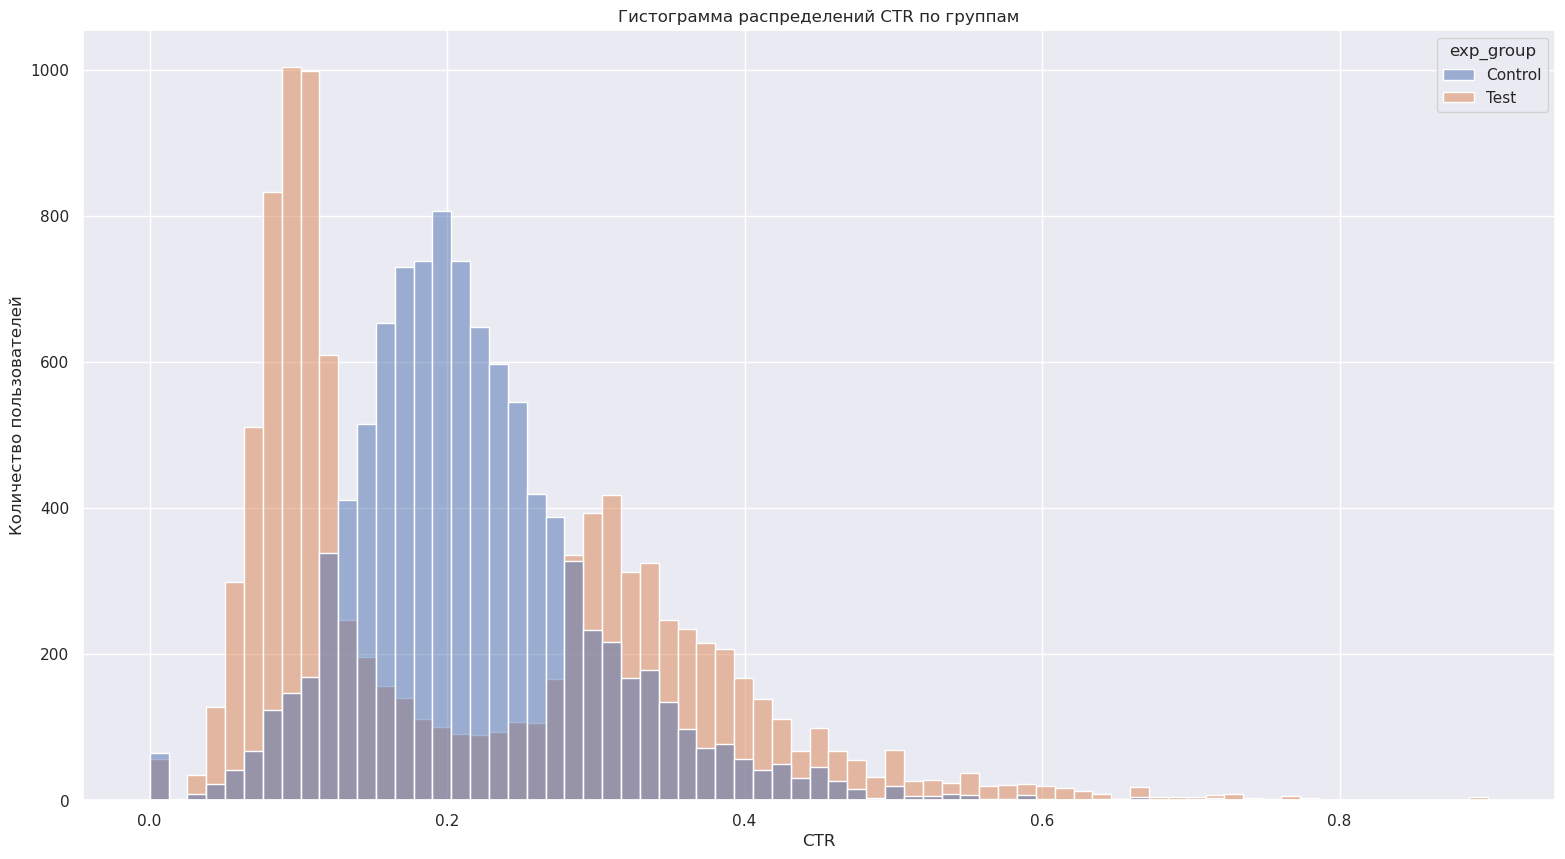

In [40]:
# Гистограмма распределений CTR по группам
sns.set(rc={'figure.figsize': (19, 10)})
sns.histplot(
    data=df,
    x='ctr',
    hue='exp_group',
    alpha=0.5,
    kde=False
)

plt.title("Гистограмма распределений CTR по группам")
plt.xlabel("CTR")
plt.ylabel("Количество пользователей")
plt.show()

In [41]:
# Извлечение значений CTR по группам для статистических тестов
control_ctr = df[df.exp_group == 'Control'].ctr
test_ctr = df[df.exp_group == 'Test'].ctr

## Применим тест Левена для проверки равенства дисперсий
- **H₀:** дисперсии двух групп равны.
- **H₁:** дисперсии двух групп различаются.

In [42]:
levene_stat, levene_p_value = levene(control_ctr, test_ctr)

print(f"Levene test p-value: {levene_p_value:.10f}")

if levene_p_value < 0.05:
    print(
        "Дисперсии статистически значимо различаются "
        f"(p = {levene_p_value:.4f})"
    )
else:
    print(
        "Нет оснований отвергнуть гипотезу о равенстве дисперсий "
        f"(p = {levene_p_value:.4f})"
    )

Levene test p-value: 0.0000000000
Дисперсии статистически значимо различаются (p = 0.0000)


## Выбор статистического теста

По графику видно, что распределения тестовой и контрольной групп сильно
различаются между собой. Если распределение в контрольной группе напоминает
нормальное, то тестовая группа далека от нормального и имеет сильные
«хвосты».
Тест Левена подтвердил, что дисперсии наших групп различаются. Из-за этого
использовать классический t-тест нецелесообразно — он чувствителен к
неравенству дисперсий, что может привести к искажению результатов.
Поэтому используем тест Уэлча — более консервативную и надёжную версию
t-теста, которая менее чувствительна к неравенству дисперсий.

## Тест Уэлча (t-тест для неравных дисперсий)
- **H₀:** средние значения CTR в двух группах равны.
- **H₁:** средние значения CTR в двух группах различаются.

In [ ]:
t_statistic, p_value = ttest_ind(control_ctr, test_ctr, equal_var=False)

print(f"t-статистика: {t_statistic:.4f}")
print(f"p-value:      {p_value:.4f}")

if p_value < 0.05:
    print(
        "\n✅ Отвергаем H0: средние значения CTR статистически значимо "
        "различаются"
    )
else:
    print(
        "\n❌ Не отвергаем H0: статистически значимых различий в средних "
        "значениях CTR нет"
    )

## Интерпретация результатов теста Уэлча
Результаты теста Уэлча показали, что средние значения CTR в двух группах
статистически значимо не различаются (p-value > 0.05).

Это означает, что у нас нет достаточных оснований утверждать, что новый
алгоритм повлиял на средний CTR.

## Проверка с помощью теста Манна-Уитни

Теперь проверим наши группы с помощью теста Манна-Уитни. Он менее
чувствителен к выбросам, так как сравнивает не средние значения, а ранги.

- **H₀:** распределение CTR в контрольной группе и тестовой группе одинаково.
- **H₁:** распределение CTR в контрольной группе и тестовой группе различается.

Используем двустороннюю альтернативу, потому что новый алгоритм мог
повлиять на CTR в любую сторону — как в положительную, так и в
отрицательную. Односторонний тест подразумевал бы, что мы заранее уверены
в улучшении показателей метрики, но в реальности мы не можем этого
гарантировать. Двусторонняя проверка даёт более объективные результаты.

In [ ]:
stat, p_value = mannwhitneyu(
    control_ctr,
    test_ctr,
    alternative='two-sided'
)

alpha = 0.05
if p_value < alpha:
    print(
        f"p-value = {p_value:.4f} → Отвергаем H₀: распределения различаются"
    )
else:
    print(
        f"p-value = {p_value:.4f} → Не отвергаем H₀: распределения не "
        "различаются"
    )

## Интерпретация результатов теста Манна-Уитни

Тест Манна-Уитни показал, что распределения CTR в контрольной и тестовой
группах статистически значимо различаются (p-value < 0.05).

На данный момент мы не можем сказать, различаются ли статистически значимо
CTR в наших группах, так как t-тест и тест Манна-Уитни показывают
противоположные результаты. Чтобы сделать окончательные выводы, прогоним
наши данные ещё через несколько тестов.

# Сглаженный CTR

Метрики имеют разную чувствительность. Чем чувствительнее наша метрика и
чем мощнее тест, проверяющий метрику, тем лучше. Когда у пользователя мало
просмотров (допустим, 1 просмотр и 1 клик — в итоге CTR будет равен 1),
оценка его CTR будет не совсем точной: может случиться так, что
пользователю просто не хватило данных (мало просмотров), чтобы проявить
большую активность в приложении. В наших группах есть такие пользователи,
а это может указывать на то, что их CTR сильно зашумлён (большая дисперсия
в данных) независимо от количества кликов. Поэтому на эти значения мы не
вполне можем полагаться.

Для более точной оценки метрики применим сглаженный CTR — метод, который
добавляет в качестве оценки общегрупповой CTR к пользователям с малым
количеством данных (просмотров). В итоге оценка метрики должна стать более
стабильной. Идея сглаженного CTR следующая: если у пользователя много
просмотров, то сглаженный CTR приблизительно будет равен реальному CTR
пользователя, а если у пользователя мало просмотров и кликов, тогда его
оценка будет очень близка к общему CTR группы.

In [43]:
#Эта функция рассчитывает CTR по формуле сглаживания Лапласа.
def get_smoothed_ctr(user_likes, user_views, global_ctr, alpha):
    """
    Гиперпараметр alpha (своего рода «сила» сглаживания) возьмём равным 5.
    Это эмпирически подобранное значение, которое хорошо работает для
    большинства задач: оно достаточно сильно сглаживает выбросы CTR у
    пользователей с малым числом просмотров, но при этом практически не
    искажает CTR пользователей с большим объёмом данных.

    Параметры
    ----------
    user_likes : Series
        Количество лайков пользователя.
    user_views : Series
        Количество просмотров пользователя.
    global_ctr : float
        Общегрупповой CTR.
    alpha : int
        Параметр сглаживания.

    Возвращает
    -------
    Series
        Сглаженный CTR пользователя.
    """
    smoothed_ctr = (
        (user_likes + alpha * global_ctr) / (user_views + alpha)
    )
    return smoothed_ctr

In [44]:
# Считаем общегрупповой CTR для контрольной и тестовой групп
global_ctr_control = (
    df[df.exp_group == 'Control'].likes.sum()
    / df[df.exp_group == 'Control'].views.sum()
)
global_ctr_test = (
    df[df.exp_group == 'Test'].likes.sum()
    / df[df.exp_group == 'Test'].views.sum()
)

# Для сохранности данных основного датафрейма сделаем копии
group_control = df[df.exp_group == 'Control'].copy()
group_test = df[df.exp_group == 'Test'].copy()

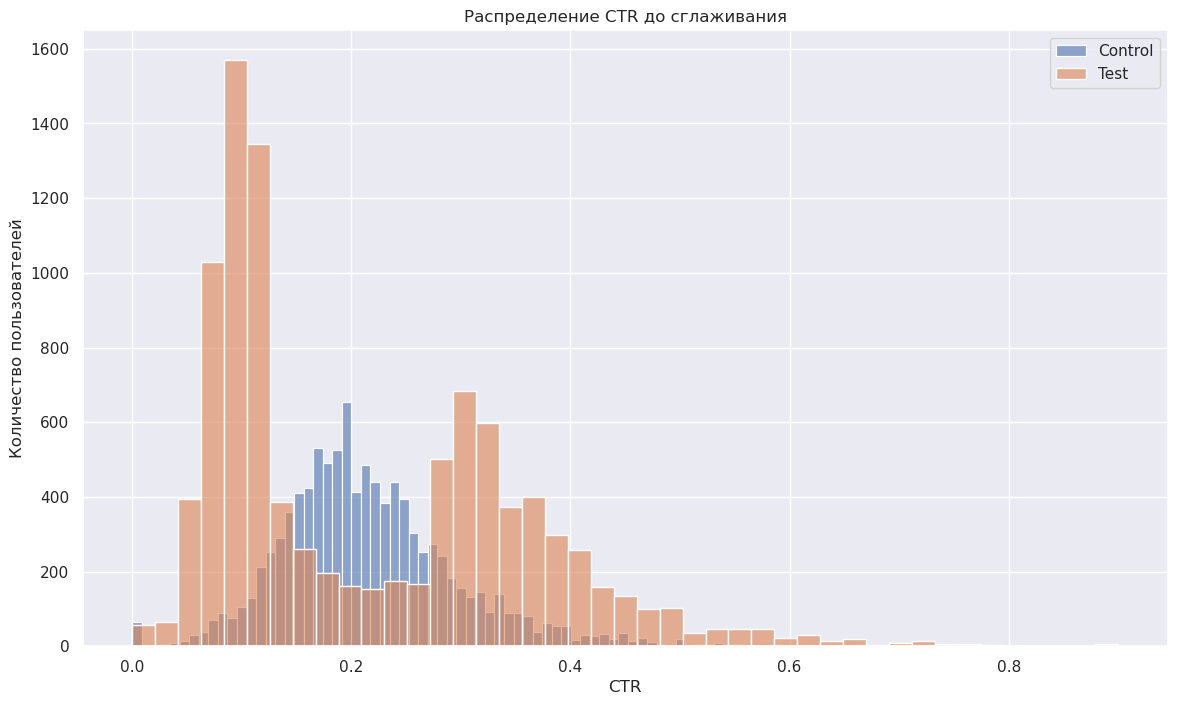

In [45]:
# Гистограмма значений до сглаживания CTR
plt.figure(figsize=(14, 8))
sns.histplot(
    group_control.ctr,
    kde=False,
    label='Control',
    alpha=0.6
)
sns.histplot(
    group_test.ctr,
    kde=False,
    label='Test',
    alpha=0.6
)
plt.title("Распределение CTR до сглаживания")
plt.xlabel("CTR")
plt.ylabel("Количество пользователей")
plt.legend()
plt.show()

In [46]:
# Создаём колонку smoothed_ctr и заполняем её сглаженными значениями
group_control['smoothed_ctr'] = group_control.apply(
    lambda x: get_smoothed_ctr(
        x['likes'], x['views'], global_ctr_control, 5
    ),
    axis=1
)
group_test['smoothed_ctr'] = group_test.apply(
    lambda x: get_smoothed_ctr(
        x['likes'], x['views'], global_ctr_test, 5
    ),
    axis=1
)

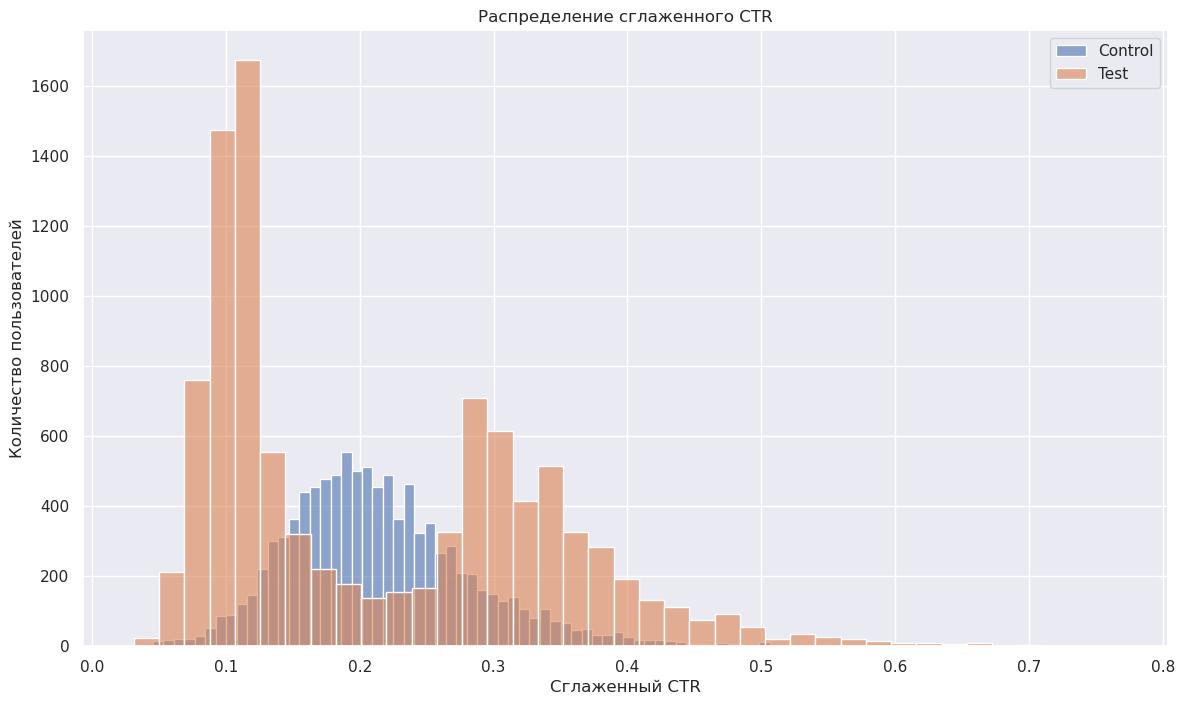

In [47]:
# Гистограмма значений после сглаживания CTR
plt.figure(figsize=(14, 8))
sns.histplot(
    group_control.smoothed_ctr,
    kde=False,
    label='Control',
    alpha=0.6
)
sns.histplot(
    group_test.smoothed_ctr,
    kde=False,
    label='Test',
    alpha=0.6
)
plt.title("Распределение сглаженного CTR")
plt.xlabel("Сглаженный CTR")
plt.ylabel("Количество пользователей")
plt.legend()
plt.show()

### Интерпретация сглаживания
Как мы видим на гистограмме, после применения сглаженного CTR «хвосты» в
наших распределениях поубавились, но различие всё ещё видно.

## Применим t-тест (тест Уэлча) для обновлённых данных

- **H₀:** средние значения сглаженного CTR в двух группах равны.
- **H₁:** средние значения сглаженного CTR в двух группах различаются.

In [48]:
stat, p_value = ttest_ind(
    group_control.smoothed_ctr,
    group_test.smoothed_ctr,
    equal_var=False
)
if p_value < 0.05:
    print(f'p_value = {p_value} - Верна альтернативная гипотеза')
else:
    print(f'p_value = {p_value} - Верна нулевая гипотеза')

p_value = 0.05166679015318525 - Верна нулевая гипотеза


## Применим тест Манна-Уитни 

- **H₀:** распределение сглаженного CTR в контрольной и тестовой группах
  одинаково (стохастически равны).
- **H₁:** распределение сглаженного CTR в контрольной и тестовой группах
  различается (стохастически не равны).

In [49]:
stat_mw_smoothed, p_value_mw_smoothed = mannwhitneyu(
    group_control['smoothed_ctr'],
    group_test['smoothed_ctr'],
    alternative='two-sided'
)

print(f"Статистика Манна-Уитни: {stat_mw_smoothed:.4f}")
print(f"p-value:               {p_value_mw_smoothed:.4f}")

if p_value_mw_smoothed < 0.05:
    print(
        f"p-value = {p_value_mw_smoothed:.4f} → "
        "Отвергаем H₀: распределения сглаженного CTR различаются"
    )
else:
    print(
        f"p-value = {p_value_mw_smoothed:.4f} → "
        "Не отвергаем H₀: распределения сглаженного CTR не различаются"
    )

Статистика Манна-Уитни: 55528353.0000
p-value:               0.0000
p-value = 0.0000 → Отвергаем H₀: распределения сглаженного CTR различаются


## Почему тесты дали разные результаты?

T-тест Уэлча не обнаружил значимых различий, однако тест Манна-Уитни —
как на исходных, так и на сглаженных данных — показал, что распределения
статистически значимо различаются. Возникает закономерный вопрос: какому
тесту доверять? Чтобы разрешить это противоречие и получить окончательное
подтверждение на уровне общегруппового CTR, не зависящее от предположений
о форме распределения, применим Пуассоновский бутстреп.

# Пуассоновский бутстреп

Теперь применим к нашим данным метод Пуассоновского бутстрепа. Принцип
работы бутстрепа в том, что мы делаем предположение, будто наши выборки
являются самым лучшим приближением к генеральной совокупности, которое у
нас есть. Из этих данных мы много раз генерируем выборки с возвращением.
Для более точной оценки будем считать не поюзерный CTR, а общегрупповой.

Чем больше просмотров у пользователя — тем больше ему можно доверять в
плане оценки реального CTR. Общегрупповой CTR автоматически это учитывает,
также он устойчив к «выбросам», которые могут исказить реальную картину
происходящего.

Бутстреп нетребователен к распределению и может считать любые виды
статистики. Для сравнения CTR двух групп нам нужны распределения CTR этих
групп, а не просто два числа. Для этого нам нужны выборки, а наши группы
являются как раз хорошей моделью генеральной совокупности. Мы будем
генерировать из каждой выборки большое количество псевдовыборок (в нашем
случае возьмём 2000 штук) с возвращением.

Для всех значений выборки мы сгенерируем, сколько раз это значение будет
попадать в псевдовыборку. Но при большой выборке (а у нас в каждой группе
около 10 тысяч пользователей) вероятность каждого значения попасть в
выборку будет очень маленькой. За счёт генерации весов из псевдовыборок
Пуассоновский бутстреп работает быстрее, чем обычный бутстреп.

In [50]:
#Данная функция реализует метод Пуассоновского бутстрепа 
def bootstrap(likes1, views1, likes2, views2, n_bootstrap=2000):
    """
    Генерируем матрицу весов размера (n_bootstrap × число_пользователей).
    2000 итераций достаточно для устойчивых оценок. Вес в данном случае
    означает, сколько раз пользователь попадёт в псевдовыборку. Poisson(1)
    даёт веса 0, 1, 2 и т. д. (в среднем 1). Преобразуем результат в целые
    числа, так как метод Пуассона возвращает float-значения, а нам нужны
    целые.

    Параметры
    ----------
    likes1 : np.array
        Массив лайков первой группы.
    views1 : np.array
        Массив просмотров первой группы.
    likes2 : np.array
        Массив лайков второй группы.
    views2 : np.array
        Массив просмотров второй группы.
    n_bootstrap : int
        Количество бутстреп-итераций.

    Возвращает
    -------
    tuple
        Два массива с распределениями глобальных CTR для каждой группы.
    """
    poisson_bootstraps1 = poisson(1).rvs(
        (n_bootstrap, len(likes1))
    ).astype(np.int64)
    poisson_bootstraps2 = poisson(1).rvs(
        (n_bootstrap, len(likes2))
    ).astype(np.int64)

    global_ctr1 = (
        (poisson_bootstraps1 * likes1).sum(axis=1)
        / (poisson_bootstraps1 * views1).sum(axis=1)
    )
    global_ctr2 = (
        (poisson_bootstraps2 * likes2).sum(axis=1)
        / (poisson_bootstraps2 * views2).sum(axis=1)
    )

    return global_ctr1, global_ctr2

In [51]:
# Берём колонки с лайками и просмотрами и преобразуем в массивы numpy
likes_control = df[df.exp_group == 'Control'].likes.to_numpy()
views_control = df[df.exp_group == 'Control'].views.to_numpy()
likes_test = df[df.exp_group == 'Test'].likes.to_numpy()
views_test = df[df.exp_group == 'Test'].views.to_numpy()

# Вызываем функцию bootstrap с подготовленными данными
ctr_control_bs, ctr_test_bs = bootstrap(
    likes_control, views_control, likes_test, views_test
)

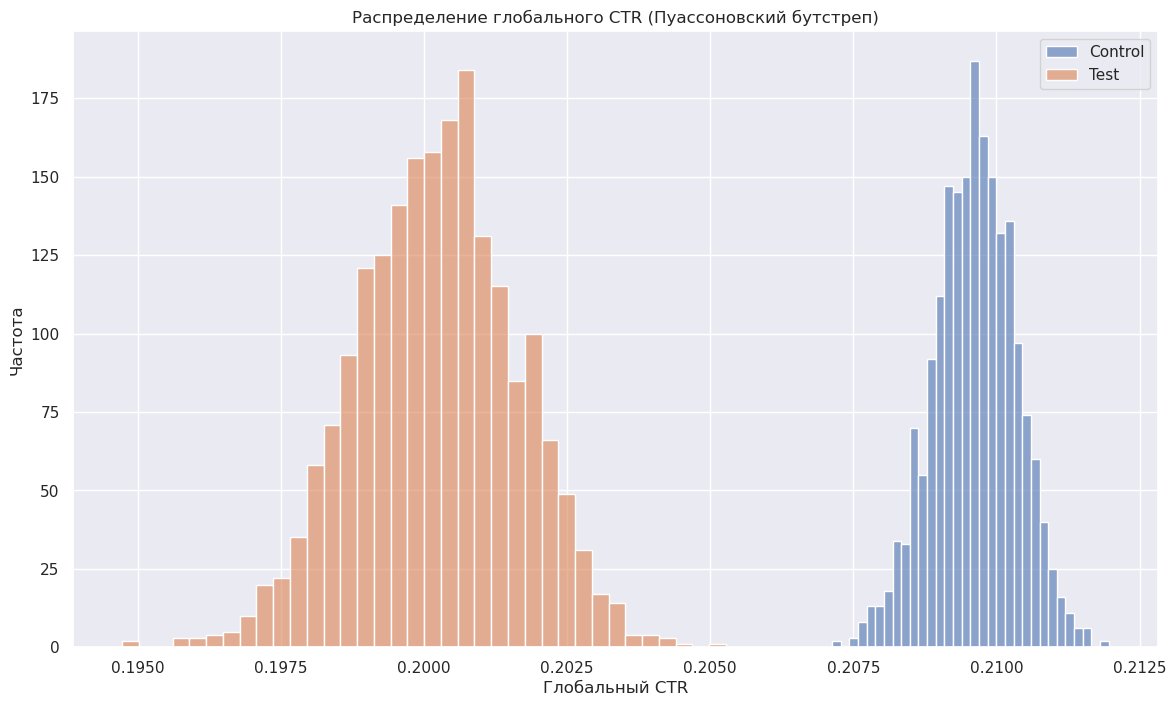

In [52]:
# Строим гистограмму получившихся распределений глобальных CTR
plt.figure(figsize=(14, 8))
sns.histplot(ctr_control_bs, label='Control', alpha=0.6)
sns.histplot(ctr_test_bs, label='Test', alpha=0.6)
plt.title("Распределение глобального CTR (Пуассоновский бутстреп)")
plt.xlabel("Глобальный CTR")
plt.ylabel("Частота")
plt.legend()
plt.show()

## Интерпретация результатов Пуассоновского бутстрепа
Как мы видим на гистограмме, распределения CTR в контрольной и тестовой
группах не пересекаются между собой. Из этого с большой долей вероятности
можно сделать вывод, что различие в CTR между контрольной и тестовой
группой статистически значимо.

## Анализ различий в результатах тестов

### Почему тесты сработали по-разному?
- **t-тест** чувствителен к выбросам и ненормальности распределения —
  дисперсии между группами отличаются. Вероятно, из-за этого t-тест не нашёл
  различий.
- **Сглаживание CTR** уменьшило влияние выбросов, но t-тест на сглаженных
  данных всё равно не показал значимость на уровне 0.05, возможно, из-за
  того, что сглаживание уменьшило разброс, но также и уменьшило различие
  между группами.
- **Тест Манна-Уитни** непараметрический и менее чувствителен к выбросам,
  поэтому он показал значимость как на исходных, так и на сглаженных данных.
- **Пуассоновский бутстреп** показал статистическую значимость, потому что
  он уменьшает влияние индивидуальных выбросов и учитывает вариацию на
  уровне всей выборки.


## Потенциальная бизнес-интерпретация
      
Новый алгоритм мог по-разному повлиять на разных пользователей. Например,
он мог улучшить рекомендации для активных пользователей (CTR вырос), но
ухудшить для неактивных (CTR упал). Это привело к тому, что в тестовой
группе стало больше пользователей с очень высоким и очень низким CTR, то
есть увеличилась дисперсия. Поэтому методы, которые чувствительны к
дисперсии и выбросам (как t-тест), не показали различие, а методы,
устойчивые к ним (Манна-Уитни, бутстреп), — показали.


# Итоговая рекомендация

Учитывая, что несколько тестов (Манна-Уитни, Пуассоновский бутстреп)
показали статистически значимое различие, и визуально распределения
отличаются, можно сделать вывод, что **новый алгоритм действительно влияет
на CTR, но не в лучшую сторону**.

Основная гипотеза, заключавшаяся в том, что новый алгоритм в тестовой
группе приведёт к увеличению CTR, на практике не подтвердилась, так как
среднее значение CTR в контрольной группе (0.2168) оказалось больше
среднего значения CTR в тестовой группе (0.2161).

В тестовой группе увеличилась дисперсия, что может означать неоднородное
влияние алгоритма на пользователей. Поэтому стоит провести дополнительный
анализ, чтобы понять, на какие подгруппы пользователей алгоритм влияет
положительно, а на какие — отрицательно. Возможно, алгоритм нужно
доработать, чтобы он равномерно улучшал рекомендации для всех
пользователей.

**На данном этапе раскатывать его на всех пользователей не рекомендуется.**
